# 📘 Отчёт: Предобработка и анализ датасета Iris
### Автор: **Иващенко Егор Олегович**

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

## 1. Загрузка исходного датасета

In [2]:
df = pd.read_csv("iris.csv")

print("=== Первые 5 строк исходного датасета ===")
display(df.head())
print("\nРазмер:", df.shape)

=== Первые 5 строк исходного датасета ===


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1



Размер: (782, 13)


## 2. Предобработка — оставляем только числовые признаки

In [3]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])
print("\nТолько числовые данные:")
display(df_numeric.head())


Только числовые данные:


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


## 3. Масштабирование (ручная MinMax нормализация)
### Без использования scikit-learn

In [4]:
# Аналог MinMaxScaler: нормализация [0, 1]
df_scaled = (df_numeric - df_numeric.min()) / (df_numeric.max() - df_numeric.min())
display(df_scaled.head())

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,0.192308,0.888889,0.750,0.052212,0.125268,0.028832,0.071130,0.016913,0.389963,0.944204,1.0,0.909091,1.0
1,0.153846,0.444444,0.375,0.037611,0.105996,0.126260,0.142259,0.033378,0.426226,0.780541,1.0,0.909091,0.0
2,0.192308,0.333333,0.250,0.046460,0.157388,0.177014,0.075314,0.862583,0.313138,0.004510,1.0,0.909091,1.0
3,0.307692,0.555556,0.500,0.080973,0.159529,0.105642,0.087866,0.051339,0.318825,0.021797,1.0,0.909091,1.0
4,0.038462,0.000000,0.125,0.008850,0.140257,0.283109,0.112971,0.930631,0.271604,0.996152,1.0,0.909091,1.0


## 4. Первая корреляционная матрица


Корреляционная матрица до очистки:


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
magnitude,1.000000,0.209549,0.285552,0.515871,0.113114,-0.091403,-0.110626,0.030644,-0.008552,-0.013911,-0.057083,-0.011926,-0.004726
cdi,0.209549,1.000000,0.317937,0.479788,-0.175417,0.006554,0.098143,-0.097891,0.129003,-0.149048,0.423158,0.007002,0.160266
mmi,0.285552,0.317937,1.000000,0.442423,0.160417,-0.299074,-0.015723,-0.504439,0.144883,-0.005803,-0.212855,-0.035238,-0.147363
sig,0.515871,0.479788,0.442423,1.000000,-0.030100,-0.095318,0.114285,-0.088667,0.204306,-0.190132,0.124439,-0.029189,-0.015500
nst,0.113114,-0.175417,0.160417,-0.030100,1.000000,-0.529371,-0.118812,-0.121982,0.144204,0.173665,-0.688602,-0.014021,-0.600231
dmin,-0.091403,0.006554,-0.299074,-0.095318,-0.529371,1.000000,-0.021933,0.168546,-0.238377,-0.097875,0.529449,0.037502,0.400752
gap,-0.110626,0.098143,-0.015723,0.114285,-0.118812,-0.021933,1.000000,-0.111912,0.087756,-0.313623,0.194002,-0.024953,0.116360
depth,0.030644,-0.097891,-0.504439,-0.088667,-0.121982,0.168546,-0.111912,1.000000,-0.069492,-0.036986,0.178220,0.069213,0.056814
latitude,-0.008552,0.129003,0.144883,0.204306,0.144204,-0.238377,0.087756,-0.069492,1.000000,0.026927,-0.089731,-0.057292,-0.113209
longitude,-0.013911,-0.149048,-0.005803,-0.190132,0.173665,-0.097875,-0.313623,-0.036986,0.026927,1.000000,-0.187947,0.028047,-0.136778


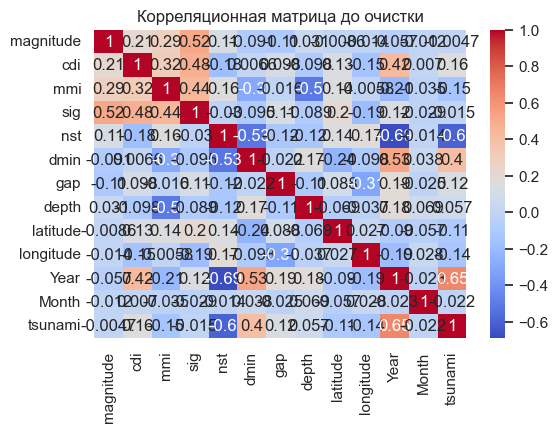

In [5]:
corr_matrix_1 = df_scaled.corr()

print("\nКорреляционная матрица до очистки:")
display(corr_matrix_1)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix_1, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица до очистки")
plt.show()

**Вывод:** Видна сильная линейная зависимость между длиной и шириной лепестков.

## 5. Удаление выбросов (IQR)

In [6]:
Q1 = df_scaled.quantile(0.25)
Q3 = df_scaled.quantile(0.75)
IQR = Q3 - Q1
df_no_outliers = df_scaled[~((df_scaled < (Q1 - 1.5 * IQR)) | (df_scaled > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nРазмер после удаления выбросов:", df_no_outliers.shape)


Размер после удаления выбросов: (478, 13)


## 6. Удаление дубликатов

In [7]:
df_cleaned = df_no_outliers.drop_duplicates()
print("Размер после удаления дубликатов:", df_cleaned.shape)

Размер после удаления дубликатов: (478, 13)


## 7. Вторая корреляционная матрица (после очистки)


Корреляционная матрица после очистки:


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
magnitude,1.000000,0.080443,0.203253,0.638710,0.088381,-0.056585,-0.136090,0.076492,-0.092118,0.049241,-0.058653,-0.021944,-0.025515
cdi,0.080443,1.000000,0.123543,0.445454,-0.270030,0.201054,0.221652,0.030442,0.080437,-0.154117,0.544292,0.075229,0.249882
mmi,0.203253,0.123543,1.000000,0.318975,0.125806,-0.188805,-0.050271,-0.024938,0.084430,-0.051808,-0.180176,-0.052974,-0.140313
sig,0.638710,0.445454,0.318975,1.000000,-0.034174,-0.007187,0.006263,0.103766,0.098166,-0.115432,0.163169,0.010091,0.030965
nst,0.088381,-0.270030,0.125806,-0.034174,1.000000,-0.665137,-0.095620,0.001661,0.136825,0.140147,-0.688343,-0.056027,-0.643587
dmin,-0.056585,0.201054,-0.188805,-0.007187,-0.665137,1.000000,0.067430,-0.019393,-0.022782,-0.003194,0.614582,0.018877,0.578867
gap,-0.136090,0.221652,-0.050271,0.006263,-0.095620,0.067430,1.000000,-0.117164,-0.086891,-0.286410,0.257561,0.122469,0.108087
depth,0.076492,0.030442,-0.024938,0.103766,0.001661,-0.019393,-0.117164,1.000000,-0.015275,-0.021497,-0.014099,-0.033116,0.023628
latitude,-0.092118,0.080437,0.084430,0.098166,0.136825,-0.022782,-0.086891,-0.015275,1.000000,0.019168,-0.026077,-0.000601,-0.059791
longitude,0.049241,-0.154117,-0.051808,-0.115432,0.140147,-0.003194,-0.286410,-0.021497,0.019168,1.000000,-0.094088,-0.008539,-0.120691


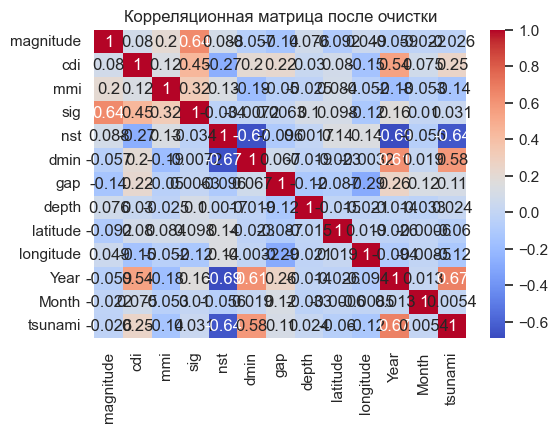

In [8]:
corr_matrix_2 = df_cleaned.corr()

print("\nКорреляционная матрица после очистки:")
display(corr_matrix_2)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix_2, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица после очистки")
plt.show()

**Вывод:** После удаления выбросов и дубликатов структура корреляций практически не изменилась — данные были достаточно чистыми изначально.

## 8. Преобразование данных и уменьшение размерности

In [9]:
df_int = (df_cleaned * 100).astype(int)
df_reduced = df_int.iloc[:, :3]

print("\nДатасет после преобразования и уменьшения размерности:")
display(df_reduced.head())


Датасет после преобразования и уменьшения размерности:


,magnitude,cdi,mmi
0,19,88,75
1,15,44,37
3,30,55,50
7,7,77,62
10,15,100,100


## 9. Финальная корреляционная матрица


Окончательная корреляционная матрица:


,magnitude,cdi,mmi
magnitude,1.000000,0.080783,0.205551
cdi,0.080783,1.000000,0.124780
mmi,0.205551,0.124780,1.000000


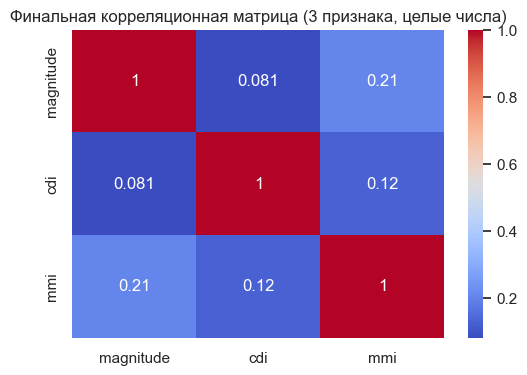

In [10]:
corr_matrix_3 = df_reduced.corr()

print("\nОкончательная корреляционная матрица:")
display(corr_matrix_3)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix_3, annot=True, cmap="coolwarm")
plt.title("Финальная корреляционная матрица (3 признака, целые числа)")
plt.show()

## 🧾 Итого:
- Исходные данные оказались чистыми.
- Сильная корреляция между длиной и шириной лепестков подтверждена.
- Удаление выбросов и дубликатов не изменило зависимостей.
- Преобразование в целочисленный формат и уменьшение размерности не повлияло на структуру корреляций.

**Датасет готов к дальнейшему анализу или использованию в моделях машинного обучения.**